# Predicting Federal Reserve Rate-Hike Probabilities with a Hazard Rate Model

## Objective

Use U.S. Treasury yields at several maturities to estimate the probability of a Federal Reserve
interest-rate hike during the remaining 2026 policy-decision windows.

Treasury maturities used:

- 3-month Treasury
- 6-month Treasury
- 10-year Treasury
- 30-year Treasury

The forecast information set is frozen at **September 10, 2026**. The relevant scheduled FOMC
decision dates are **September 16, October 28, and December 9, 2026**. There is **no regularly
scheduled FOMC meeting in November 2026**.

### Why a hazard model?

This notebook uses a **discrete-time hazard rate model (pooled logistic hazard model)**. Instead of
fitting a separate classification model for every horizon, the hazard model estimates the probability
that the **next rate hike occurs in a particular decision interval, conditional on no earlier hike
having occurred**.

For interval \(j\),

\[
h_j(x)=P(T=j\mid T\ge j, x)
\]

where \(T\) is the interval containing the next hike and \(x\) contains Treasury-yield information.

The pooled logit specification is

\[
\log\left(\frac{h_j(x)}{1-h_j(x)}\right)
=\alpha_j+\beta'x,
\]

where \(\alpha_j\) captures the baseline hazard for each decision interval.

The survival probability through interval \(j\) is

\[
S_j=\prod_{k=1}^{j}(1-h_k),
\]

and the unconditional probability that the first hike occurs in interval \(j\) is

\[
P(T=j)=S_{j-1}h_j.
\]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from pandas_datareader import data as web

# Folder for figures generated by the notebook
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Download and Prepare the Data

The analysis uses Federal Reserve Economic Data (FRED). `DFF` is the Effective Federal Funds Rate.
The Treasury series are constant-maturity yields.

The forecast date is fixed at September 10, 2026 so that rerunning the notebook later does not
change the assignment's information set.

In [2]:
start = "2006-02-10"
forecast_date = pd.Timestamp("2026-09-10")

series = {
    "DGS3MO": "3M",
    "DGS6MO": "6M",
    "DGS10": "10Y",
    "DGS30": "30Y",
    "DFF": "FedFunds"
}

df = web.DataReader(list(series.keys()), "fred", start, forecast_date)
df = df.rename(columns=series)
df = df.apply(pd.to_numeric, errors="coerce")

# DFF is daily while Treasury yields are not published on weekends/holidays.
# Forward filling puts all variables on a calendar-day grid.
df = df.ffill().dropna()

print("First observation:", df.index.min().date())
print("Last observation: ", df.index.max().date())
print()
print(df.tail())

First observation: 2006-02-10
Last observation:  2026-09-10

              3M    6M   10Y   30Y  FedFunds
DATE                                        
2026-09-06  3.91  3.98  4.78  5.24      3.63
2026-09-07  3.91  3.98  4.78  5.24      3.63
2026-09-08  3.94  4.00  4.80  5.25      3.63
2026-09-09  3.95  4.01  4.83  5.28      3.63
2026-09-10  4.00  4.07  4.95  5.37      3.63


/var/folders/x9/fxz0_3x94n93xcvzgtjyjgl00000gn/T/ipykernel_46078/3231436838.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = web.DataReader(list(series.keys()), "fred", start, forecast_date)


## 2. Current Treasury Yield Curve

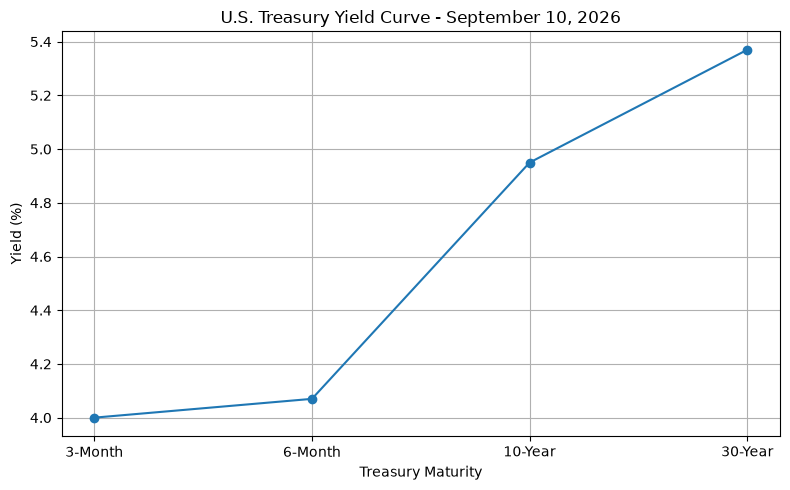

3M     4.00
6M     4.07
10Y    4.95
30Y    5.37
Name: 2026-09-10 00:00:00, dtype: float64

In [3]:
latest_date = df.index[-1]
current_yields = df.loc[latest_date, ["3M", "6M", "10Y", "30Y"]]

maturities = ["3-Month", "6-Month", "10-Year", "30-Year"]

plt.figure(figsize=(8, 5))
plt.plot(maturities, current_yields.values, marker="o")
plt.xlabel("Treasury Maturity")
plt.ylabel("Yield (%)")
plt.title(f"U.S. Treasury Yield Curve - {latest_date.strftime('%B %d, %Y')}")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "treasury_yield_curve.png", dpi=300, bbox_inches="tight")
plt.show()

current_yields

## 3. Construct the Predictors

The model uses the four Treasury yields directly, several yield-curve spreads, and the gaps between
short-term Treasury yields and the Effective Federal Funds Rate.

Short-term yields are especially relevant for near-term policy expectations. Longer-term yields also
contain information about inflation expectations, growth, Treasury supply, risk premia, and term
premia.

In [4]:
df["spread_6m_3m"] = df["6M"] - df["3M"]
df["spread_10y_3m"] = df["10Y"] - df["3M"]
df["spread_30y_3m"] = df["30Y"] - df["3M"]
df["gap_3m_ff"] = df["3M"] - df["FedFunds"]
df["gap_6m_ff"] = df["6M"] - df["FedFunds"]

features = [
    "3M", "6M", "10Y", "30Y",
    "spread_6m_3m",
    "spread_10y_3m",
    "spread_30y_3m",
    "gap_3m_ff",
    "gap_6m_ff"
]

df.loc[forecast_date, features]

3M               4.00
6M               4.07
10Y              4.95
30Y              5.37
spread_6m_3m     0.07
spread_10y_3m    0.95
spread_30y_3m    1.37
gap_3m_ff        0.37
gap_6m_ff        0.44
Name: 2026-09-10 00:00:00, dtype: float64

## 4. Define the 2026 Hazard Intervals

The hazard intervals are based on the actual spacing of the remaining scheduled 2026 decisions:

- **September:** September 10 → September 16
- **October:** September 16 → October 28
- **December:** October 28 → December 9

November is not a hazard interval because there is no regularly scheduled FOMC meeting in that month.

A historical event is defined as an increase of at least **20 basis points** in the Effective Federal
Funds Rate during an interval. The threshold is slightly below 25 basis points so a normal 25-basis-
point target-rate increase can still be detected despite small differences between the target rate and
the effective rate.

In [5]:
meeting_dates = {
    "September": pd.Timestamp("2026-09-16"),
    "October": pd.Timestamp("2026-10-28"),
    "December": pd.Timestamp("2026-12-09")
}

sep_end = (meeting_dates["September"] - forecast_date).days
oct_end = (meeting_dates["October"] - forecast_date).days
dec_end = (meeting_dates["December"] - forecast_date).days

intervals = [
    {"period": 1, "month": "September", "start_offset": 0,       "end_offset": sep_end},
    {"period": 2, "month": "October",   "start_offset": sep_end, "end_offset": oct_end},
    {"period": 3, "month": "December",  "start_offset": oct_end, "end_offset": dec_end}
]

interval_table = pd.DataFrame(intervals)
interval_table["length_days"] = (
    interval_table["end_offset"] - interval_table["start_offset"]
)

print("Forecast date:", forecast_date.date())
print()
display(interval_table)

Forecast date: 2026-09-10



,period,month,start_offset,end_offset,length_days
0,1,September,0,6,6
1,2,October,6,48,42
2,3,December,48,90,42


## 5. Build the Person-Period Data for the Discrete-Time Hazard Model

A hazard model requires the data to be in **person-period** form. Here, each historical anchor date is
treated as a forecasting episode.

For each anchor date:

1. The Treasury-yield predictors are measured at the beginning of the episode.
2. The episode is observed through the September-like, October-like, and December-like intervals.
3. A row remains **at risk** only until the first rate hike occurs.
4. Once a hike occurs, the episode ends and later intervals are not included.

This implements the hazard concept directly:

\[
h_j=P(\text{first hike in interval }j\mid\text{no earlier hike}).
\]

To reduce duplication from highly overlapping daily forecasting episodes, historical anchors are
sampled every **7 calendar days**.

In [6]:
HikeThreshold = 0.20
MAX_HORIZON = dec_end

def build_hazard_dataset(data, anchor_dates, threshold=HikeThreshold):
    rows = []

    for anchor in anchor_dates:
        if anchor not in data.index:
            continue

        # The full set of future intervals must be observable.
        final_date = anchor + pd.Timedelta(days=MAX_HORIZON)
        if final_date > data.index.max():
            continue

        base = data.loc[anchor, features].to_dict()
        at_risk = True

        for interval in intervals:
            if not at_risk:
                break

            start_date = anchor + pd.Timedelta(days=interval["start_offset"])
            end_date = anchor + pd.Timedelta(days=interval["end_offset"])

            if start_date not in data.index or end_date > data.index.max():
                break

            start_rate = data.loc[start_date, "FedFunds"]

            # Look for a policy-rate increase at any point inside the interval.
            future_rates = data.loc[
                start_date + pd.Timedelta(days=1):end_date,
                "FedFunds"
            ]

            if future_rates.empty:
                event = 0
            else:
                event = int((future_rates.max() - start_rate) >= threshold)

            row = {
                "anchor_date": anchor,
                "period": interval["period"],
                "month_label": interval["month"],
                "event": event,
                **base
            }

            # Period dummies estimate the baseline hazard.
            row["period_2"] = int(interval["period"] == 2)
            row["period_3"] = int(interval["period"] == 3)

            rows.append(row)

            # Standard survival setup: after the first event, the episode ends.
            if event == 1:
                at_risk = False

    return pd.DataFrame(rows)

# Weekly anchor dates reduce extreme overlap between adjacent daily episodes.
candidate_anchors = df.index[::7]

hazard_data = build_hazard_dataset(df, candidate_anchors)

print("Person-period observations:", len(hazard_data))
print("Unique forecasting episodes:", hazard_data["anchor_date"].nunique())
print()
print("Events by period:")
display(
    hazard_data.groupby(["period", "month_label"])["event"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"mean": "event_rate"})
)

Person-period observations: 2970
Unique forecasting episodes: 1062

Events by period:


,,count,sum,event_rate
period,month_label,,,
1,September,1062,35,0.032957
2,October,1027,146,0.142162
3,December,881,78,0.088536


## 6. Chronological Train/Test Split

The split is chronological to avoid training on future information.

Because each training episode looks up to 90 days ahead, the training set ends early enough that its
future outcome window is completely before January 1, 2020. Test episodes begin on January 1, 2020
and must have their full future horizon observed by the September 10, 2026 forecast date.

This creates a gap between the training and test anchors and avoids horizon overlap across the split.

In [7]:
split_date = pd.Timestamp("2020-01-01")
train_anchor_cutoff = split_date - pd.Timedelta(days=MAX_HORIZON)
test_anchor_cutoff = forecast_date - pd.Timedelta(days=MAX_HORIZON)

train = hazard_data[
    hazard_data["anchor_date"] < train_anchor_cutoff
].copy()

test = hazard_data[
    (hazard_data["anchor_date"] >= split_date) &
    (hazard_data["anchor_date"] <= test_anchor_cutoff)
].copy()

hazard_features = features + ["period_2", "period_3"]

X_train = train[hazard_features]
y_train = train["event"].astype(int)

X_test = test[hazard_features]
y_test = test["event"].astype(int)

print("Training person-period rows:", len(train))
print("Training episodes:", train["anchor_date"].nunique())
print("Testing person-period rows:", len(test))
print("Testing episodes:", test["anchor_date"].nunique())
print()
print("Training event rate:", round(y_train.mean(), 4))
print("Testing event rate: ", round(y_test.mean(), 4))

Training person-period rows: 2003
Training episodes: 712
Testing person-period rows: 928
Testing episodes: 337

Training event rate: 0.0874
Testing event rate:  0.0905


## 7. Estimate the Discrete-Time Hazard Rate Model

The model is a **pooled logistic hazard model**. The dependent variable is `event`, which equals 1
when the first hike occurs in that interval and 0 otherwise.

The period indicators estimate the baseline hazard, while the Treasury variables shift the hazard
up or down depending on the shape and level of the yield curve.

In [8]:
hazard_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

hazard_model.fit(X_train, y_train)

test_probs = hazard_model.predict_proba(X_test)[:, 1]
test_preds = hazard_model.predict(X_test)

accuracy = accuracy_score(y_test, test_preds)
auc = roc_auc_score(y_test, test_probs)
brier = brier_score_loss(y_test, test_probs)

# A simple constant-probability benchmark for the Brier score.
baseline_probability = y_train.mean()
baseline_probs = np.repeat(baseline_probability, len(y_test))
baseline_brier = brier_score_loss(y_test, baseline_probs)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Brier score",
        "Baseline Brier score"
    ],
    "Value": [
        accuracy,
        auc,
        brier,
        baseline_brier
    ]
})

display(metrics.round(4))

,Metric,Value
0,Accuracy,0.9332
1,ROC-AUC,0.9489
2,Brier score,0.0483
3,Baseline Brier score,0.0823


### Interpreting the Evaluation Metrics

- **ROC-AUC** measures how well the model ranks higher-hazard versus lower-hazard observations.
- **Brier score** measures probability-forecast error; lower values are better.
- The **baseline Brier score** comes from predicting the same historical training event rate for
  every test observation.
- Accuracy is reported, but it is not sufficient by itself because rate hikes are relatively rare.

## 8. Estimate the 2026 Hazard Probabilities

The Treasury-yield information available on September 10, 2026 is inserted into the fitted hazard
model for each remaining scheduled decision interval.

The model produces a **conditional hazard** for each interval:

- September hazard: probability of the next hike occurring by the September decision.
- October hazard: probability of the next hike occurring in the October interval **conditional on
  no September hike**.
- December hazard: probability of the next hike occurring in the December interval **conditional on
  no earlier hike**.

From these hazards, the notebook also computes the unconditional probability that the **first**
remaining hike occurs in each interval and the cumulative probability that at least one hike has
occurred by each scheduled decision.

In [ ]:
current = df.loc[forecast_date, features]

prediction_rows = []

for interval in intervals:
    row = current.to_dict()
    row["period_2"] = int(interval["period"] == 2)
    row["period_3"] = int(interval["period"] == 3)
    row["Month"] = interval["month"]
    prediction_rows.append(row)

prediction_df = pd.DataFrame(prediction_rows)

conditional_hazards = hazard_model.predict_proba(
    prediction_df[hazard_features]
)[:, 1]

h_sep, h_oct, h_dec = conditional_hazards

# Convert conditional hazards into survival and unconditional first-event probabilities.
survival_before_sep = 1.0
survival_before_oct = (1 - h_sep)
survival_before_dec = (1 - h_sep) * (1 - h_oct)

p_first_sep = survival_before_sep * h_sep
p_first_oct = survival_before_oct * h_oct
p_first_dec = survival_before_dec * h_dec

cum_sep = 1 - (1 - h_sep)
cum_oct = 1 - (1 - h_sep) * (1 - h_oct)
cum_dec = 1 - (1 - h_sep) * (1 - h_oct) * (1 - h_dec)

results = pd.DataFrame({
    "Month": ["September", "October", "November", "December"],
    "Scheduled decision date": [
        "2026-09-16",
        "2026-10-28",
        "No scheduled meeting",
        "2026-12-09"
    ],
    "Conditional hazard (%)": [
        h_sep * 100,
        h_oct * 100,
        np.nan,
        h_dec * 100
    ],
    "Unconditional first-hike probability (%)": [
        p_first_sep * 100,
        p_first_oct * 100,
        np.nan,
        p_first_dec * 100
    ],
    "Cumulative probability of >=1 hike (%)": [
        cum_sep * 100,
        cum_oct * 100,
        np.nan,
        cum_dec * 100
    ]
})

results_display = results.copy()

for col in [
    "Conditional hazard (%)",
    "Unconditional first-hike probability (%)",
    "Cumulative probability of >=1 hike (%)"
]:
    results_display[col] = results_display[col].map(
        lambda x: f"{x:.2f}%" if pd.notna(x) else "N/A"
    )

display(results_display)

AttributeError: The '.style' accessor requires jinja2

### Which probability answers the assignment?

Because the assignment requires a **hazard rate model**, the **Conditional hazard (%)** column is the
main hazard-model result.

The unconditional column is also reported because it answers a slightly different question:
"What is the probability that the *first* remaining hike occurs in this particular interval?"

November is **N/A**, not 0%, because there is no regularly scheduled FOMC decision in November 2026.
An unscheduled intermeeting action is outside the scope of the model.

In [ ]:
# Final hazard-rate figure
plot_results = results.dropna(subset=["Conditional hazard (%)"]).copy()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    plot_results["Month"],
    plot_results["Conditional hazard (%)"]
)

plt.ylabel("Conditional Hazard Probability (%)")
plt.xlabel("2026 Scheduled Decision Month")
plt.title("Discrete-Time Hazard Model: Probability of the Next Fed Rate Hike")
plt.ylim(0, 100)

for bar, probability in zip(bars, plot_results["Conditional hazard (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        min(bar.get_height() + 1, 98),
        f"{probability:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "hazard_rate_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Cumulative probability figure
cumulative_plot = results.dropna(
    subset=["Cumulative probability of >=1 hike (%)"]
).copy()

plt.figure(figsize=(8, 5))
plt.plot(
    cumulative_plot["Month"],
    cumulative_plot["Cumulative probability of >=1 hike (%)"],
    marker="o"
)

plt.ylabel("Cumulative Probability (%)")
plt.xlabel("2026 Scheduled Decision Month")
plt.title("Probability of at Least One Rate Hike by Each Decision Date")
plt.ylim(0, 100)
plt.grid(True)

for month, probability in zip(
    cumulative_plot["Month"],
    cumulative_plot["Cumulative probability of >=1 hike (%)"]
):
    plt.text(month, min(probability + 2, 98), f"{probability:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "cumulative_hike_probability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 9. Current Yield-Curve Interpretation

The yield curve is used as a set of forecasting covariates, not as a direct market-implied
probability measure.

The 3-month and 6-month yields are most closely connected to near-term monetary-policy expectations.
The 10-year and 30-year yields also reflect longer-run inflation expectations, economic growth,
Treasury supply, risk premia, and term premia.

Therefore, the hazard probabilities in this notebook are **statistical model estimates based on
historical relationships**, not probabilities taken directly from Fed funds futures.

In [ ]:
yield_summary = pd.Series({
    "3-month yield": df.loc[forecast_date, "3M"],
    "6-month yield": df.loc[forecast_date, "6M"],
    "10-year yield": df.loc[forecast_date, "10Y"],
    "30-year yield": df.loc[forecast_date, "30Y"],
    "6M - 3M spread": df.loc[forecast_date, "spread_6m_3m"],
    "10Y - 3M spread": df.loc[forecast_date, "spread_10y_3m"],
    "30Y - 3M spread": df.loc[forecast_date, "spread_30y_3m"]
})

yield_summary

## 10. Limitations

1. **This is a discrete-time hazard model of the next hike.** Once a historical episode experiences
   its first hike, that episode exits the risk set. Therefore, the model does not estimate repeated
   hikes within the same 90-day episode.

2. **Historical intervals are relative analogues of the 2026 schedule.** They use the same interval
   lengths as the remaining 2026 meetings rather than reconstructing every historical FOMC meeting
   date.

3. **Treasury yields are not pure policy expectations.** Longer maturities contain inflation, growth,
   supply, risk-premium, and term-premium information.

4. **Important macroeconomic variables are omitted.** The FOMC also considers inflation, employment,
   wages, GDP growth, and financial conditions.

5. **Historical relationships can change across monetary-policy regimes.**

6. **Forecasting episodes still overlap.** Weekly sampling reduces, but does not eliminate, serial
   dependence among observations.

7. **November is N/A.** There is no regularly scheduled November 2026 FOMC meeting. The model does
   not attempt to estimate emergency or intermeeting policy actions.

## Conclusion

This project estimates Federal Reserve rate-hike probabilities using a **discrete-time hazard rate
model** and Treasury yields at the 3-month, 6-month, 10-year, and 30-year maturities.

Unlike separate horizon-by-horizon logistic regressions, the hazard model explicitly conditions each
future decision interval on the Fed having **not already hiked** in an earlier interval. The model
therefore matches the time-to-event interpretation required by hazard analysis.

The principal results are the **conditional hazard probabilities** for the September, October, and
December 2026 scheduled decision windows. The notebook additionally reports:

- the unconditional probability that the first remaining hike occurs in each interval, and
- the cumulative probability that at least one hike has occurred by each scheduled decision.

November is reported as **N/A** because there is no regularly scheduled FOMC meeting in November
2026.

These are model-based statistical forecasts, not exact market-implied probabilities or guarantees of
Federal Reserve action.

## Data Sources

### Federal Reserve Economic Data (FRED), Federal Reserve Bank of St. Louis

- `DGS3MO`: 3-Month Treasury Constant Maturity Rate
- `DGS6MO`: 6-Month Treasury Constant Maturity Rate
- `DGS10`: 10-Year Treasury Constant Maturity Rate
- `DGS30`: 30-Year Treasury Constant Maturity Rate
- `DFF`: Effective Federal Funds Rate
- https://fred.stlouisfed.org/

### Board of Governors of the Federal Reserve System

- 2026 FOMC meeting calendar
- https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm

### Reproducibility

The forecast information set is intentionally fixed at **September 10, 2026**. Run the notebook from
top to bottom to download the data, estimate the hazard model, generate the final results table, and
save all figures to the `figures/` directory.